# 📱 Smartphone Addiction Prediction

In this notebook, we predict whether a person is addicted to smartphone usage (`addicted_label`: 0 = No, 1 = Yes) using machine learning.

### Pipeline Overview:
1. **Import Libraries & Load Data**
2. **Exploratory Data Analysis (EDA)**
3. **Feature Engineering** (creating intuitive behavioral & usage metrics)
4. **Data Preprocessing** (encoding categorical variables)
5. **Model Training (5-Fold Stratified Cross-Validation with HistGradientBoosting)**
6. **Model Evaluation (Accuracy, Precision, Recall, F1-score, ROC-AUC)**
7. **Inference & Submission File Generation**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load Datasets


In [2]:
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

print(f"Train Dataset Shape: {train_df.shape}")
print(f"Test Dataset Shape:  {test_df.shape}")
train_df.head()


Train Dataset Shape: (691369, 14)
Test Dataset Shape:  (296302, 13)


## 2. Exploratory Data Analysis (EDA)


In [3]:
# Check summary statistics
train_df.describe()


In [4]:
# Check missing values in train and test sets
missing_train = train_df.isnull().sum()
missing_test = test_df.isnull().sum()

missing_table = pd.DataFrame({
    'Train Missing': missing_train,
    'Train %': (missing_train / len(train_df)) * 100,
    'Test Missing': missing_test,
    'Test %': (missing_test / len(test_df)) * 100
})
missing_table[missing_table['Train Missing'] > 0]


Class Balance:
addicted_label
1    70.942435
0    29.057565
Name: proportion, dtype: float64


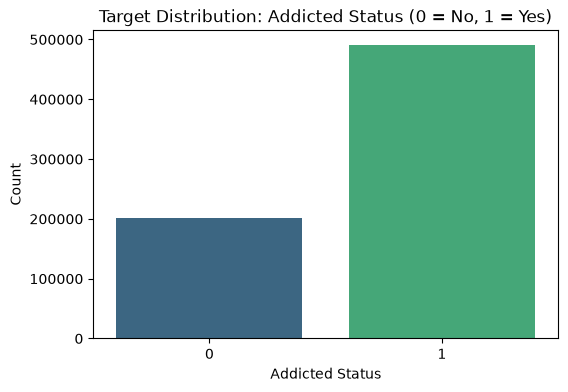

In [5]:
# Check target class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='addicted_label', palette='viridis')
plt.title('Target Distribution: Addicted Status (0 = No, 1 = Yes)')
plt.xlabel('Addicted Status')
plt.ylabel('Count')
plt.show()

print("Class Balance:")
print(train_df['addicted_label'].value_counts(normalize=True) * 100)


## 3. Feature Engineering

We create simple, domain-specific features that help the model detect smartphone addiction patterns:
- **`entertainment_hours`**: Social media hours + gaming hours.
- **`entertainment_ratio`**: Proportion of daily screen time spent on entertainment.
- **`unproductive_to_productive`**: Ratio of entertainment time to study/work time.
- **`screen_time_to_awake_ratio`**: Proportion of awake hours spent looking at a screen.
- **`notifications_per_awake_hour`**: Notification frequency during active awake hours.
- **`minutes_per_app_open`**: Average minutes spent on the phone per app open.
- **`weekend_vs_daily_diff`**: Increase in screen time on weekends compared to weekdays.
- **`num_missing`**: Total missing fields per person (captures incomplete profile signal).


In [6]:
def create_features(df):
    data = df.copy()
    eps = 1e-5  # small number to prevent division by zero
    
    # 1. Entertainment time (social media + gaming)
    data['entertainment_hours'] = data['social_media_hours'] + data['gaming_hours']
    
    # 2. Proportion of screen time spent on social media, gaming, and entertainment
    data['social_media_ratio'] = data['social_media_hours'] / (data['daily_screen_time_hours'] + eps)
    data['gaming_ratio'] = data['gaming_hours'] / (data['daily_screen_time_hours'] + eps)
    data['work_study_ratio'] = data['work_study_hours'] / (data['daily_screen_time_hours'] + eps)
    data['entertainment_ratio'] = data['entertainment_hours'] / (data['daily_screen_time_hours'] + eps)
    
    # 3. Unproductive vs productive time ratio
    data['unproductive_to_productive'] = data['entertainment_hours'] / (data['work_study_hours'] + eps)
    
    # 4. Awake time & screen exposure ratio
    data['awake_hours'] = 24.0 - data['sleep_hours']
    data['screen_time_to_awake_ratio'] = data['daily_screen_time_hours'] / (data['awake_hours'] + eps)
    
    # 5. Frequency of notifications and app opens
    data['notifications_per_awake_hour'] = data['notifications_per_day'] / (data['awake_hours'] + eps)
    data['app_opens_per_awake_hour'] = data['app_opens_per_day'] / (data['awake_hours'] + eps)
    data['notifications_per_app_open'] = data['notifications_per_day'] / (data['app_opens_per_day'] + eps)
    data['minutes_per_app_open'] = (data['daily_screen_time_hours'] * 60.0) / (data['app_opens_per_day'] + eps)
    
    # 6. Weekend vs daily difference
    data['weekend_vs_daily_diff'] = data['weekend_screen_time'] - data['daily_screen_time_hours']
    data['weekend_vs_daily_ratio'] = data['weekend_screen_time'] / (data['daily_screen_time_hours'] + eps)
    
    # 7. Count of missing fields
    raw_columns = [c for c in df.columns if c not in ['id', 'addicted_label']]
    data['num_missing'] = df[raw_columns].isnull().sum(axis=1)
    
    # 8. Encode categorical columns
    if 'gender' in data.columns:
        data['gender'] = data['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})
    if 'academic_work_impact' in data.columns:
        data['academic_work_impact'] = data['academic_work_impact'].astype(str).str.strip().str.lower().map({'no': 0, 'yes': 1})
    if 'stress_level' in data.columns:
        data['stress_level'] = data['stress_level'].astype(str).str.strip().str.lower().map({'low': 0, 'medium': 1, 'high': 2})
        
    return data

train_features = create_features(train_df)
test_features = create_features(test_df)

print(f"Total features created: {train_features.shape[1] - 2}")
train_features.head()


Total features created: 27


## 4. Model Training (5-Fold Stratified Cross-Validation)

We use **`HistGradientBoostingClassifier`** because:
1. It **natively handles missing values (`NaN`)**, so we don't have to drop rows or manually guess imputations.
2. It is highly optimized and fast for large datasets (~700k records).
3. We use **5-Fold Stratified Cross-Validation** to train 5 diverse models and average their predictions for a robust, high-scoring submission.


In [7]:
# Define feature columns (X) and target (y)
feature_cols = [c for c in train_features.columns if c not in ['id', 'addicted_label']]
X = train_features[feature_cols]
y = train_features['addicted_label']
X_test = test_features[feature_cols]

# 5-Fold Stratified Cross-Validation setup
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_probabilities = np.zeros(len(train_df))
test_predictions = np.zeros(len(test_df))
models = []

print(f"Starting 5-Fold Cross Validation on {len(X)} samples with {len(feature_cols)} features...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]
    
    # Initialize Gradient Boosting model
    model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.08,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=1.0,
        random_state=42 + fold
    )
    
    # Train the model
    model.fit(X_train_fold, y_train_fold)
    models.append(model)
    
    # Predict validation probabilities
    val_preds = model.predict_proba(X_val_fold)[:, 1]
    oof_probabilities[val_idx] = val_preds
    
    # Accumulate test predictions across all 5 folds
    test_predictions += model.predict_proba(X_test)[:, 1] / n_splits
    
    # Fold metrics
    fold_auc = roc_auc_score(y_val_fold, val_preds)
    fold_f1 = f1_score(y_val_fold, (val_preds >= 0.5).astype(int))
    fold_acc = accuracy_score(y_val_fold, (val_preds >= 0.5).astype(int))
    
    print(f"Fold {fold+1} Metrics -> ROC-AUC: {fold_auc:.5f} | F1-Score: {fold_f1:.5f} | Accuracy: {fold_acc:.5f}")


Starting 5-Fold Cross Validation on 691369 samples with 27 features...

Fold 1 Metrics -> ROC-AUC: 0.96176 | F1-Score: 0.92921 | Accuracy: 0.89892
Fold 2 Metrics -> ROC-AUC: 0.96230 | F1-Score: 0.93044 | Accuracy: 0.90065
Fold 3 Metrics -> ROC-AUC: 0.96265 | F1-Score: 0.93032 | Accuracy: 0.90047
Fold 4 Metrics -> ROC-AUC: 0.96333 | F1-Score: 0.93096 | Accuracy: 0.90143
Fold 5 Metrics -> ROC-AUC: 0.96239 | F1-Score: 0.92997 | Accuracy: 0.89999


## 5. Overall Model Evaluation (Out-Of-Fold)


       OVERALL CROSS-VALIDATION RESULTS
ROC-AUC Score: 0.96248
F1-Score:      0.93018
Accuracy:      90.03%
Precision:     92.42%
Recall:        93.62%

Classification Report:
              precision    recall  f1-score   support

           0     0.8392    0.8126    0.8257    200895
           1     0.9242    0.9362    0.9302    490474

    accuracy                         0.9003    691369
   macro avg     0.8817    0.8744    0.8779    691369
weighted avg     0.8995    0.9003    0.8998    691369



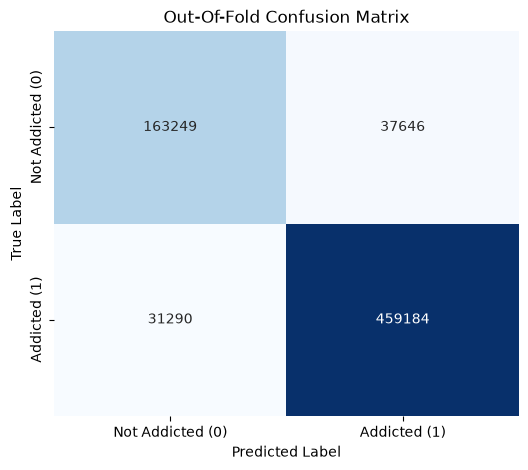

In [8]:
# Evaluate overall cross-validation performance
oof_preds_binary = (oof_probabilities >= 0.5).astype(int)

overall_auc = roc_auc_score(y, oof_probabilities)
overall_f1 = f1_score(y, oof_preds_binary)
overall_acc = accuracy_score(y, oof_preds_binary)
overall_prec = precision_score(y, oof_preds_binary)
overall_rec = recall_score(y, oof_preds_binary)

print("=" * 50)
print("       OVERALL CROSS-VALIDATION RESULTS")
print("=" * 50)
print(f"ROC-AUC Score: {overall_auc:.5f}")
print(f"F1-Score:      {overall_f1:.5f}")
print(f"Accuracy:      {overall_acc * 100:.2f}%")
print(f"Precision:     {overall_prec * 100:.2f}%")
print(f"Recall:        {overall_rec * 100:.2f}%")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y, oof_preds_binary, digits=4))

# Plot Confusion Matrix
cm = confusion_matrix(y, oof_preds_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Addicted (0)', 'Addicted (1)'],
            yticklabels=['Not Addicted (0)', 'Addicted (1)'])
plt.title('Out-Of-Fold Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## 6. Generate Final Submission File


In [9]:
# Create submission dataframe
submission = pd.DataFrame({
    'id': test_df['id'],
    'addicted_label': test_predictions
})

# Save to submission.csv
submission.to_csv('submission.csv', index=False)

print(f"Submission saved successfully to 'submission.csv'!")
print(f"Total rows: {len(submission)}")
print(f"Missing values: {submission.isnull().sum().to_dict()}")
submission.head(10)


Submission saved successfully to 'submission.csv'!
Total rows: 296302
Missing values: {'id': 0, 'addicted_label': 0}
